# 02 — Preprocess CDFG JSON → PyG tensors


In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
from ll_hls4ml.config import load_config
from ll_hls4ml.data.tensorize import create_graph_tensors
from ll_hls4ml.data.vocab import save_vocab, vocab_scan, load_vocab, make_local_types_global
from ll_hls4ml.viz.dataset import analyze_graph_dataset
from ll_hls4ml.viz.eda import plot_vocab_counts


In [ ]:
cfg = load_config()

kernel_subset = ["2layer", "3layer", "conv1d", "conv2d", "exemplar"]
max_archives = 1

In [22]:
from ll_hls4ml.io.discovery import iter_graph_paths
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import tqdm

graph_dir = cfg.graph_dir
paths = list(iter_graph_paths(graph_dir, kernel_subset, max_archives))

# def process_graph(path):
#     graph_path = path[1]
#     ll_path = str(graph_path).replace("graphs", "ll").replace(".json", ".ll")
#     make_local_types_global(graph_path, ll_path)

# with ThreadPoolExecutor(max_workers=8) as executor:
#     list(tqdm.tqdm(
#         executor.map(process_graph, paths),
#         total=len(paths),
#         desc="Parsing graph files for building vocab",
#     ))

Parsing graph files for building vocab:  26%|██▋       | 34/129 [00:47<01:04,  1.47it/s]

Error loading JSON: /home/brend/projects/data/graphs/2layer/archive_1/81ae65ee-db11-4ff1-835c-a62e010c7087.json: unexpected end of data: line 1 column 35932455 (char 35932454)


Parsing graph files for building vocab:  27%|██▋       | 35/129 [00:47<00:52,  1.78it/s]

Error loading JSON: /home/brend/projects/data/graphs/2layer/archive_1/81e31826-4f38-42ec-8aae-9e3908ec1dee.json: unexpected end of data: line 1 column 44184988 (char 44184987)


Parsing graph files for building vocab:  28%|██▊       | 36/129 [00:47<00:44,  2.08it/s]

...

Parsing graph files for building vocab:  30%|███       | 39/129 [00:48<00:23,  3.82it/s]

Error loading JSON: /home/brend/projects/data/graphs/2layer/archive_1/88f4bd06-8e7c-46a5-87d9-f0663989f0e9.json: unexpected end of data: line 1 column 30995455 (char 30995454)
Error loading JSON: /home/brend/projects/data/graphs/2layer/archive_1/89764b29-5f6a-4ed2-a10b-3af46d34f830.json: unexpected end of data: line 1 column 22633538 (char 22633537)


Parsing graph files for building vocab:  32%|███▏      | 41/129 [00:48<00:17,  5.14it/s]

Error loading JSON: /home/brend/projects/data/graphs/2layer/archive_1/9e52bee8-89a0-453b-84a3-b4b1bc4be36d.json: unexpected end of data: line 1 column 32763905 (char 32763904)
Error loading JSON: /home/brend/projects/data/graphs/2layer/archive_1/a3158e1f-fab8-45a4-8dbf-fcbf6b6d04a1.json: unexpected end of data: line 1 column 19805780 (char 19805779)
Error loading JSON: /home/brend/projects/data/graphs/2layer/archive_1/a4b77544-b0d8-4465-8a89-14f47365346c.json: unexpected end of data: line 1 column 11311708 (char 11311707)


Parsing graph files for building vocab: 100%|██████████| 129/129 [02:16<00:00,  1.06s/it]


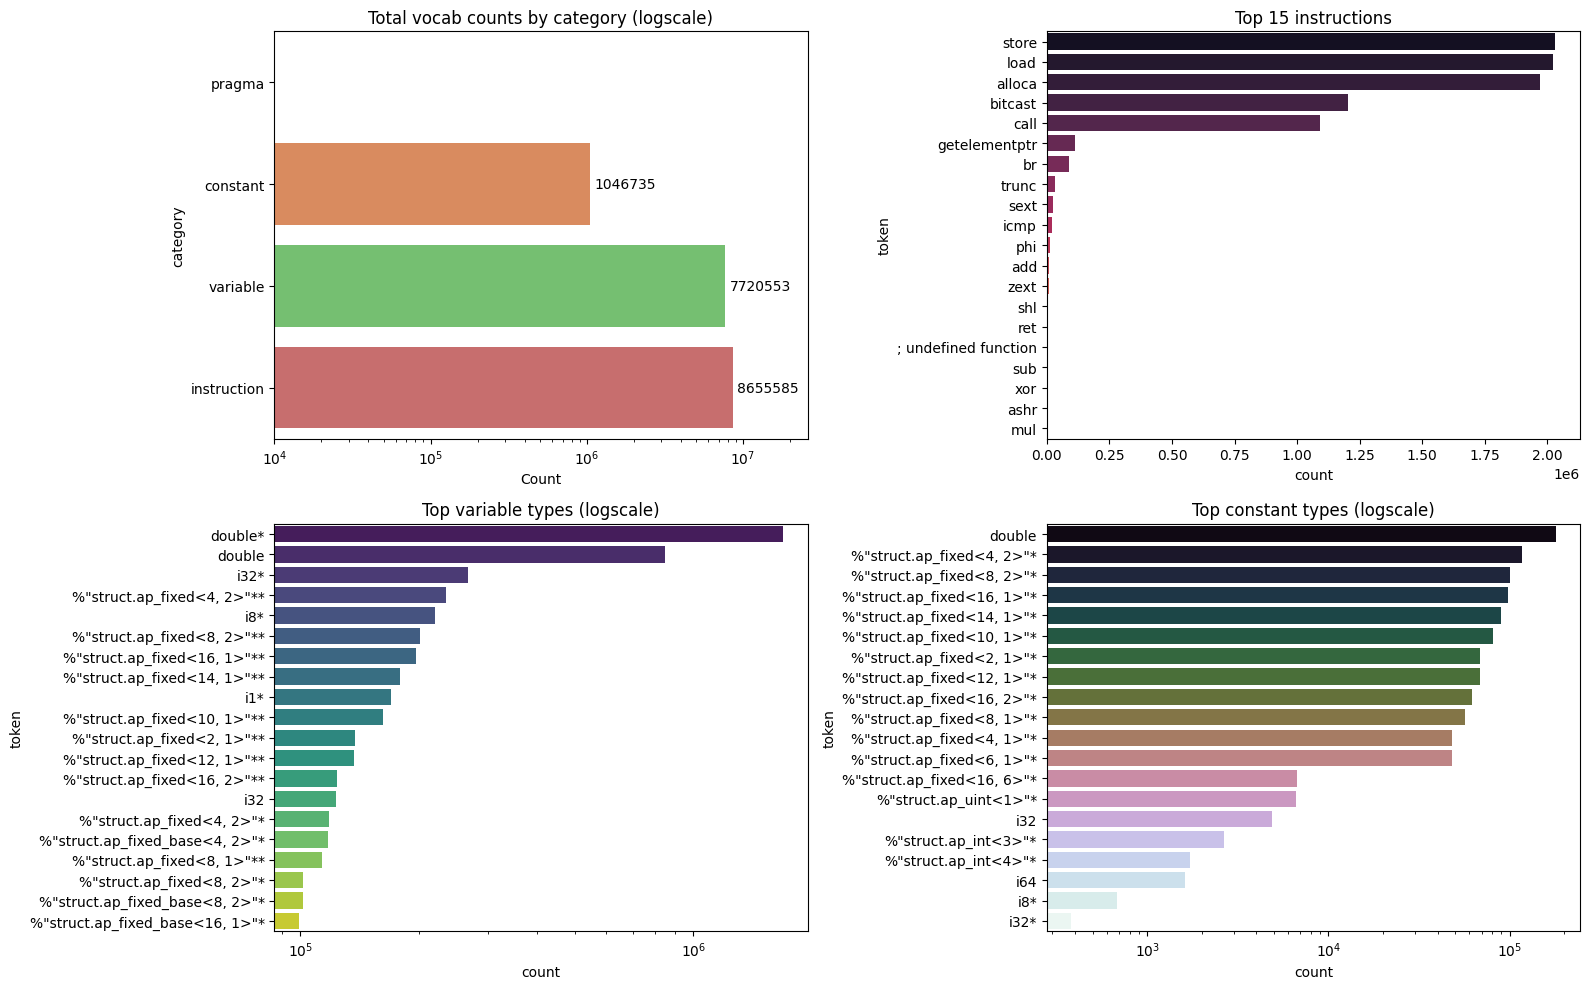

{'; undefined function': 1,
 'UNK': 0,
 '[external]': 2,
 'add': 3,
 'alloca': 4,
 'and': 5,
 'ashr': 6,
 'bitcast': 7,
 'br': 8,
 'call': 9,
 'getelementptr': 10,
 'icmp': 11,
 'load': 12,
 'lshr': 13,
 'mul': 14,
 'phi': 15,
 'ret': 16,
 'sdiv': 17,
 'select': 18,
 'sext': 19,
 'shl': 20,
 'srem': 21,
 'store': 22,
 'sub': 23,
 'trunc': 24,
 'urem': 25,
 'xor': 26,
 'zext': 27}
4
{'constant': {'%"struct.ap_fixed<10, 1>"*': 80896,
              '%"struct.ap_fixed<12, 1>"*': 68464,
              '%"struct.ap_fixed<14, 1>"*': 89648,
              '%"struct.ap_fixed<16, 1, AP_RND_CONV, AP_SAT>"*': 10,
              '%"struct.ap_fixed<16, 1>"*': 98528,
              '%"struct.ap_fixed<16, 2>"*': 61672,
              '%"struct.ap_fixed<16, 6>"*': 6748,
              '%"struct.ap_fixed<2, 1>"*': 68888,
              '%"struct.ap_fixed<4, 1, AP_RND_CONV, AP_SAT>"*': 18,
              '%"struct.ap_fixed<4, 1>"*': 48240,
              '%"struct.ap_fixed<4, 2>"*': 116884,
              '%"struc

In [26]:
instruction_vocab, max_pos, vocab_counts = vocab_scan(
    cfg.graph_dir, kernel_subset=kernel_subset, max_archives=max_archives
)
save_vocab(instruction_vocab, max_pos, "../artifacts/vocab/new_vocab.json", vocab_counts=vocab_counts)
instruction_vocab, max_pos, vocab_counts = load_vocab("../artifacts/vocab/new_vocab.json")
plot_vocab_counts(vocab_counts)
from pprint import pprint
pprint(instruction_vocab)
print(max_pos)
pprint(vocab_counts)


In [27]:
create_graph_tensors(cfg.graph_dir, cfg.tensor_dir, instruction_vocab, kernel_subset=kernel_subset, max_archives=max_archives, n_workers=8)

Processing graph files into PyTorch tensors: 100%|██████████| 129/129 [01:51<00:00,  1.15it/s]


Types not parsed by embedder:
   129  %"union.(unnamed union at /opt/Xilinx/2025/Vitis/common/technology/autopilot/etc/ap_common.h:721:3)"*
    19  %struct.exponent_scale17_t*
    19  %struct.exponent_scale17_t**
    17  %struct.exponent_scale18_t*
    17  %struct.exponent_scale18_t**
    16  %struct.exponent_scale19_t**
    16  %struct.exponent_scale19_t*
    16  %struct.exponent_scale16_t**
    16  %struct.exponent_scale16_t*
    15  %struct.exponent_scale23_t*
    15  %struct.exponent_scale23_t**
    14  %struct.exponent_scale22_t*
    14  %struct.exponent_scale22_t**
    13  %struct.exponent_scale21_t*
    13  %struct.exponent_scale21_t**
    13  %struct.exponent_scale25_t**
    13  %struct.exponent_scale25_t*
    13  %struct.exponent_scale24_t*
    13  %struct.exponent_scale24_t**
    12  %struct.exponent_scale20_t**
    12  %struct.exponent_scale20_t*
    12  %struct.exponent_scale15_t*
    12  %struct.exponent_scale15_t**
    12  %struct.exponent_scale26_t**
    12  %struct.expo